## FEM 1D

## Introducción

El Método de Elementos Finitos (**FEM**) es un método numérico que nos permite computar las soluciones de [ecuaciones en dervidas parciales](https://es.wikipedia.org/wiki/Ecuaci%C3%B3n_en_derivadas_parciales) ([**PDE**](https://en.wikipedia.org/wiki/Partial_differential_equation)). Para que tenga solución única se necesita el valor de la solución en la frontera (condición de borde). Con esta notebook comenzaremos a desarrollar el método en su versión unidimensional con un ejemplo de utilidad que tiene solución analítica: [**la ecuación de Poisson**](https://es.wikipedia.org/wiki/Ecuaci%C3%B3n_de_Poisson).

$$ \left \{ \begin{array}{l} -u^{''}=f \ \ \text{ para } \ \ x\in I=\left(0,1 \right) \\   u(0)=u(1)=0   \end{array} \right . \tag{1}$$

donde $f(x)$ es conocida.
- - -
**Ejemplo 1**:  Se puede verificar que la función $u = \frac{x(1-x)}{2}$ es solución cuando $f=1$ y $u(0)=u(1)=0$ (es decir para un intervalo $I=\left(0,1 \right)$).
- - -
Usaremos este ejemplo para testear el método.

## Formulación variacional

La solución utilizando FEM siempre comienza por reescribir la Ec. (1) en la forma denominada **forma variacional** o **forma débil**. Multiplicamos la ecuación por una función de prueba $v$ (**función test**).

$$-\int_{0}^{1}u^{''} \ \ v \ \ dx = \int_{0}^{1}f \ \ v \ \ dx \tag{2}$$

Note que la parte izquierda de esta ecuación tiene una segunda derivada. Por razones que veremos más adelante, es conveniente bajar el orden de esta derivada. Para esto se integra por partes:

$$-\left[ \left. u^{'}v \ \ \right |_{0}^{1}-\int_{0}^{1}v^{'}u^{'}dx\right] = \int_{0}^{1} fvdx$$

computando en los límites:

$$\int_{0}^{1}v^{'}u^{'}dx + u^{'}(0)v(0) - u^{'}(1)v(1) = \int_{0}^{1} fvdx.$$

A la función $v$ le pedimos que cumpla $v(0)=0$ y $v(1)=0$ (esto si no nos interesa o no tenemos restricción para los valores de la función en $u^{'}$ en 0 y 1). De esta forma la ecuación anterior nos queda:

$$\int_{0}^{1}v^{'}u^{'} \ \ dx = \int_{0}^{1} fv \ \ dx  \ \ \ \ \forall v \in V_{0}.\tag{4}$$

A $v$ le vamos a pedir que se comporte bien, por eso tendrá que ser:

$$v\in C^{\infty}_c(0,1)$$

Veremos más adelante que no hace falta pedirle tanto.

Otro comentario más, a la función $u$ (que es la solución que estamos buscando) se le suele decir función ensayo (**trial function**).



## Aproximación por elementos finitos

El siguiente paso es aproximar $u$. En este caso por otra continua y lineal a trozos. Utilizaremos el $V_{h}$ (definido en la Ec. (4) del [tutorial anterior](https://nbviewer.jupyter.org/github/rirastorza/Intro2FEM/blob/master/Polinomios_constantes_atrozo/polinomios.ipynb)). También le pediremos que se cumpla $v(0)=0$ y $v(1)=0$. Entonces resolveremos:

$$\int_{0}^{1}u_{h}^{'}v^{'} \ \ dx = \int_{0}^{1} fv \ \ dx   \ \ \ \ \forall v \in V_{h} \tag{5}$$

A esto se le dice método de [Galerkin](https://en.wikipedia.org/wiki/Boris_Galerkin), en honor a quien lo propuso. Remarcamos que tanto $u_{h}$ como $v$ pertenecen al espacio $V_{h}$, esto es porque también $u_{h}$ vale cero en los bordes.

### Sistema de ecuaciones lineales

Lo que vamos a hacer es pasar de una ecuación con integrales (Ec. (5)) a un sistema de ecuaciones lineales cuya solución serán unas constantes $\alpha_{i}$, que nos permitirán construir nuestra solución aproximada $u_{h}$. El sistema de ecuaciones lineales lo expresaremos de la forma:

$$A\alpha = b$$

donde $A$ es una matriz de $(n-1)\times (n-1)$, $\alpha$ y $b$ son vectores de $(n-1)\times 1$. Tomaremos la función de prueba $v=\varphi_{i}(x)$ con $i=1,\dots,n-1$ (las funciones sombrero), dado que $v$ debe ser cero en los bordes (por eso no están $i=0$ e $i=n$). Por lo tanto si expresamos la Ec. (5) con esta $v$ tendremos:

$$ \int_{0}^{1}u_{h}^{'}\varphi_{i}^{'}(x) \ \ dx = \int_{0}^{1} f \varphi_{i}(x) \ \ dx    \tag{6}.$$

Esto vale para $i=1,\dots,n-1 $. Como $u_{h}$ también pertenece a $V_{h}$ entonces también la podemos escribir como combinación lineal de las funciones sombrero ($\varphi_{j}$, le ponemos otro subíndice para distinguirlas):

$$ u_{h} = \sum_{j=1}^{n-1} \alpha_{j} \varphi_{j} \tag{7}.$$

esto lo reemplazo en la Ec. (6) y nos queda:

$$ \int_{0}^{1} \left( \sum_{j=1}^{n-1} \alpha_{j} \varphi_{j} \right)^{'} \varphi_{i}^{'} dx = \int_{0}^{1} \sum_{j=1}^{n-1} \alpha_{j} \left( \varphi_{j} \right)^{'} \varphi_{i}^{'} dx = \sum_{j=1}^{n-1} \alpha_{j} \int_{0}^{1} \varphi_{j}^{'} \varphi_{i}^{'} dx = \int_{0}^{1} f \varphi_{i} \ \ dx.$$

Ahora introducimos la notación:

$$ A_{ij} = \int_{0}^{1} \varphi_{j}^{'} \varphi_{i}^{'} dx \ \ \text{con} \ \ i,j=1,\dots, n-1 \tag{8}$$

$$b_{i}=\int_{0}^{1} f \varphi_{i} \ \ dx \ \ \text{con} \ \ i=1,\dots, n-1\tag{9}$$

Noten que aquí las incógnitas son los $\alpha_{j}$ debemos expresar esto de la siguiente forma:

$$ \begin{bmatrix} A_{11} & A_{12} & \cdots & A_{1(n-1)} \\ A_{21} & \ddots & \cdots & \vdots \\ \vdots &  &  & \vdots \\  A_{(n-1)1} & \cdots & \cdots & A_{(n-1)(n-1)} \end{bmatrix} \begin{bmatrix} \xi_{1} \\ \xi_{2} \\ \vdots \\ \xi_{n-1} \end{bmatrix}= \begin{bmatrix} b_{1} \\ b_{2} \\ \vdots \\ b_{n-1} \end{bmatrix} \tag{10}$$

A la matriz $A$ se le dice **matriz de rigidéz** (stifness matrix) y a $b$ se le dice **vector de cargas** (load vector).

***

El **algoritmo** deberá realizar las siguientes operaciones:

1. Crear la malla en $I$, esto determinará el espacio $V_{h}$
2. Computar $A$ y $b$ y armar la matriz $A$ y el vector $b$ como vimos en clase.
3. Resolver el sistema de ecuaciones
4. Calcular la solución aproximada: $u_{h}= \sum_{j=1}^{n-1} \alpha_{j} \varphi_{j}$

***

### Implementamos el algoritmo

Recordemos que las funciones sombrero se definen de la forma:


$$ \varphi_{j}(x_{i})= \left \{ \begin{array}{l} \frac{x-x_{i-1}}{h_{i}} \ \ \text{ si } \ \ x\in I_{i} \\  \frac{x_{i+1}-x}{h_{i+1}}  \ \ \text{ si }  \ \ x\in I_{i+1}\\ 0  \ \ \text{caso contrario} \end{array} \right .$$

entonces su derivada será:

$$ \varphi^{'}_{j}(x_{i})= \left \{ \begin{array}{l} \frac{1}{h_{i}} \ \ \text{ si } \ \ x\in I_{i} \\  \frac{-1}{h_{i+1}}  \ \ \text{ si }  \ \ x\in I_{i+1}\\ 0  \ \ \text{caso contrario} \end{array} \right .$$

Ahora veremos que valores toma el producto $\varphi_{i}^{'}\varphi_{j}^{'}$.

In [ ]:
#librerias
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#Definimos la función sombrero
def phi(x,xi,i):
    hi = xi[1]-xi[0]
    if i == 0:
        if xi[i] <= x < xi[i+1]:
            phi = (xi[i+1]-x)/(xi[i+1]-xi[i])
        else:
            phi = 0
    elif i == len(xi):
        if (xi[i-1] < x <= xi[i]):
            phi = (x-xi[i-1])/(xi[i]-xi[i-1])
        else:
            phi = 0
    else:
        if (xi[i-1] < x <= xi[i]):
            phi = (x-xi[i-1])/(xi[i]-xi[i-1])
        elif xi[i] < x <= xi[i+1]:
            phi = (xi[i+1]-x)/(xi[i+1]-xi[i])
        else:
            phi = 0

    return phi

#Definimos la función derivada de la función sombrero
def dphi(x,xi,i):
    hi = xi[1]-xi[0]
    if i == 0:
        if xi[i] <= x < xi[i+1]:
            dphi = -1/(xi[i+1]-xi[i])
        else:
            dphi = 0
    elif i == len(xi):
        if (xi[i-1] < x <= xi[i]):
            dphi = 1/(xi[i]-xi[i-1])
        else:
            dphi = 0
    else:
        if (xi[i-1] < x <= xi[i]):
            dphi = 1/(xi[i]-xi[i-1])
        elif xi[i] < x <= xi[i+1]:
            dphi = -1/(xi[i+1]-xi[i])
        else:
            dphi = 0

    return dphi

def evalua_phi(x,xi,i):
  y=np.array([])
  for k in range(len(x)):
    y=np.append(y,phi(x[k],xi,i))

  return y

def evalua_dphi(x,xi,i):
  y=np.array([])
  for k in range(len(x)):
    y=np.append(y,dphi(x[k],xi,i))

  return y


h:  0.2


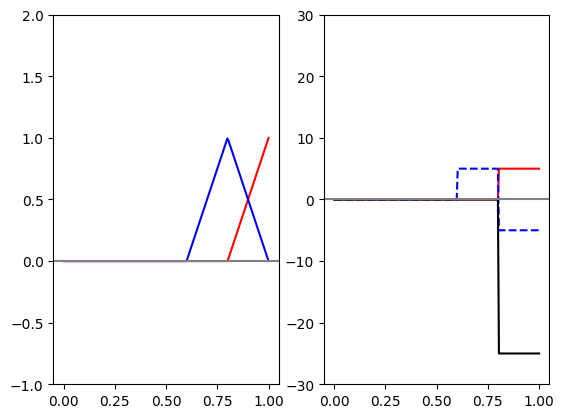

In [ ]:
N = 5 #numero de intervalos
n_nodos = N+1 #cantidad de nodos
xi = np.linspace(0,1,n_nodos) #nodos equiespaciados
x = np.linspace(0,1,200) #continuo

print('h: ',xi[1]-xi[0])

I = 5
J = 4

phi_I = evalua_phi(x,xi,I)#phi_i
phi_J = evalua_phi(x,xi,J)#phi_j
dphi_I = evalua_dphi(x,xi,I)#phi_i
dphi_J = evalua_dphi(x,xi,J)#phi_j
fig, axs = plt.subplots(1,2)
axs[0].plot(x,phi_I,'r')
axs[0].plot(x,phi_J,'b')
axs[0].set_ylim(-1,2)
axs[0].axhline(0, color='gray');
axs[1].plot(x,dphi_I,'r-')
axs[1].plot(x,dphi_J,'b--')
axs[1].plot(x,dphi_J*dphi_I,'k')
axs[1].set_ylim(-30,30);
axs[1].axhline(0, color='gray');

**Ejercicio 1:** Armar una malla de $N$ intervalos en el $(0,1)$.

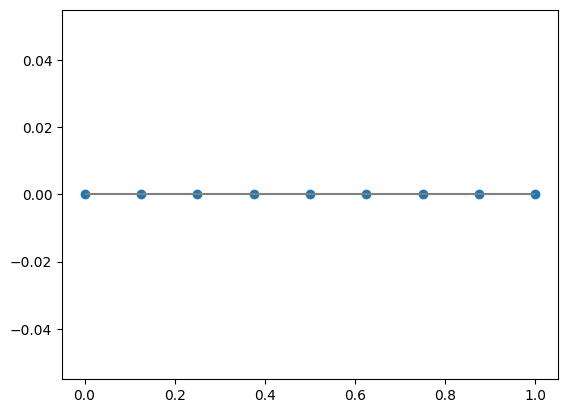

In [ ]:
#Armar la malla de N intervalos
N = 8 #numero de intervalos
n_nodos = N+1 #cantidad de nodos
xi = np.linspace(0,1,n_nodos) #nodos equiespaciados
plt.plot(xi,np.zeros(len(xi)),'o')
plt.hlines(0,0,1, color='grey')

**Ejercicio 2:** Definir la función f, y dos funciones que generen la matriz de rigidez y el lado derecho del sistema. Las funciones deben tomar como parametro los nodos y en el caso de la función para construir el lado derecho del sistema, también la función $f$.

In [ ]:
#Computo del lado derecho del sistema

def f(x):
  f=1
  return f

def LoadVector(xi,f):
    N=len(xi)
    b=np.zeros(N)
    h=xi[1]-xi[0]
    for k in range(N-1):
      s=np.zeros(2)
      nodo=xi[k]
      nodo_pos=xi[k+1]
      s[0]=(h/2)*f(nodo)
      s[1]=(h/2)*f(nodo_pos)
      b[k]=b[k]+s[0]
      b[k+1]=b[k+1]+s[1]
    return b

def Stiffnes(xi):
  N=len(xi)
  A=np.zeros((N,N))
  h=xi[1]-xi[0]
  for k in range(N-1):
    S=np.zeros((2,2))
    nodo=xi[k]
    nodo_pos=xi[k+1]
    nodo_index=np.array([k,k+1])
    S[0,0]=1/h
    S[0,1]=-1/h
    S[1,0]=S[0,1]
    S[1,1]=1/h
    A[np.ix_(nodo_index,nodo_index)]=A[np.ix_(nodo_index,nodo_index)]+S
  return A



**Ejercicio 3:** Generar la matriz y el vector del sistema y resolver. Luego graficar y comparar con la solución exacta.

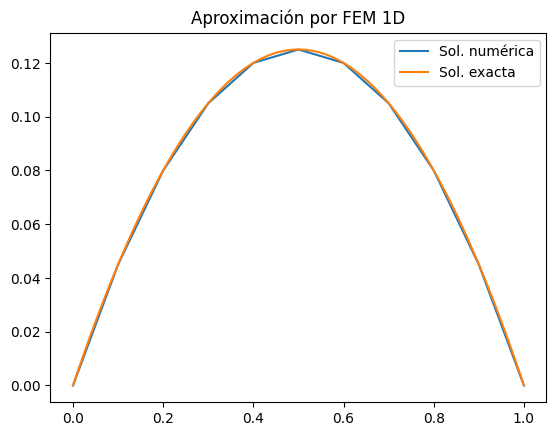

In [ ]:
def u_ex(x):
  y=x*(1-x)/2
  return y

def fem1D(N,f,u_ex):
  n_nodos = N+1 #cantidad de nodos
  xi = np.linspace(0,1,n_nodos) #nodos equiespaciados
  A=Stiffnes(xi)
  b=LoadVector(xi,f)
  #incorporo dato de borde
  A[0,:]=np.zeros(len(xi))
  A[0,0]=1
  b[0]=0
  A[len(xi)-1,:]=np.zeros(len(xi))
  A[len(xi)-1,len(xi)-1]=1
  b[len(xi)-1]=0
  uh=np.linalg.solve(A,b)
  plt.plot(xi,uh,label="Sol. numérica")
  x=np.linspace(0,1,100)
  u=u_ex(x)
  plt.plot(x,u,label="Sol. exacta")
  plt.legend()
  plt.title('Aproximación por FEM 1D')
  return uh

uh=fem1D(10,f,u_ex)


**Ejercicio 4:** Calcular para distinta cantidad de intervalos $\|u-u_h\|_{L^2}$ y $\|u'-u_h'\|_{L^2}$ donde $u_h$ es la solución numérica. ¿Podemos estimar el orden del método?.

In [ ]:
##completar



---



## Bases cuadráticas

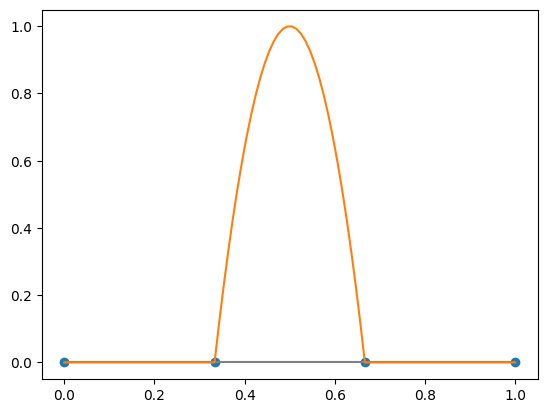

In [ ]:
N = 3 #numero de intervalos
n_nodos = N+1 #cantidad de nodos
xi = np.linspace(0,1,n_nodos) #nodos equiespaciados
plt.plot(xi,np.zeros(len(xi)),'o')
plt.hlines(0,0,1, color='grey')

def phi(x,xi,i):
  hi=xi[1]-xi[0]
  if xi[i]<=x<=xi[i+1]:
    y=(-4/hi**2)*(x-xi[i])*(x-xi[i+1])
  else:
    y=0
  return y

x=np.linspace(0,1,100)
y=np.array([])
for xj in x:
  y=np.append(y,phi(xj,xi,1))
plt.plot(x,y)

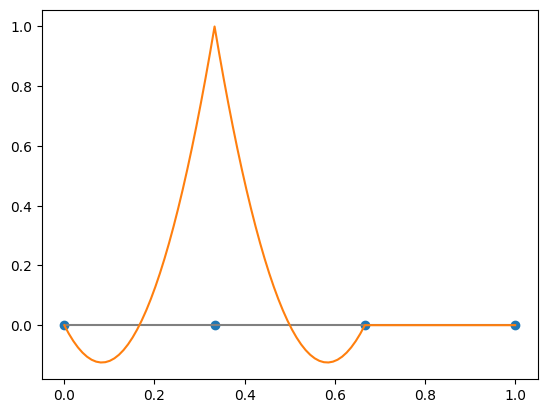

In [ ]:
N = 3 #numero de intervalos
n_nodos = N+1 #cantidad de nodos
xi = np.linspace(0,1,n_nodos) #nodos equiespaciados
plt.plot(xi,np.zeros(len(xi)),'o')
plt.hlines(0,0,1, color='grey')

def phi(x,xi,i):
  hi=xi[1]-xi[0]
  if xi[i-1]<=x<=xi[i]:
    a=(xi[i-1]+xi[i])/2
    y=(2/hi**2)*(x-xi[i-1])*(x-a)
  elif xi[i]<=x<=xi[i+1]:
    a=(xi[i]+xi[i+1])/2
    y=(2/hi**2)*(x-xi[i+1])*(x-a)
  else:
    y=0
  return y

x=np.linspace(0,1,100)
y=np.array([])
for xj in x:
  y=np.append(y,phi(xj,xi,1))
plt.plot(x,y)

## Bases cubicas